# 03 — Model Training v5 (10 activities, no per-user norm, deployable)

IDCNN with legacy Adam optimizer. Global normalization only — matches device exactly.

In [1]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers, callbacks
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.13.0


In [2]:
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models/v5')
RESULTS_DIR = Path('../results/v5')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')
X_train_orig = np.load(DATA_DIR / 'X_train_original.npy')

with open(DATA_DIR / 'preprocessing_info.pkl', 'rb') as f:
    info = pickle.load(f)

NUM_CLASSES = info['num_classes']
WINDOW_SIZE = info['window_size']
NUM_FEATURES = info['num_features']
ACTIVITIES = info['activities']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Classes: {NUM_CLASSES} | Features: {NUM_FEATURES}')
print(f'Activities: {ACTIVITIES}')
print(f'Dropped: {info.get("dropped_activities", [])}')
print(f'Saving to: {MODEL_DIR} and {RESULTS_DIR}')

Train: (27036, 128, 8) | Test: (922, 128, 8)
Classes: 10 | Features: 8
Activities: ['ear_rubbing', 'forehead_rubbing', 'hair_pulling', 'hand_tapping', 'knuckles_cracking', 'nail_biting', 'nape_rubbing', 'sitting', 'smoking', 'standing']
Dropped: ['hand_scratching']
Saving to: ../models/v5 and ../results/v5


## IDCNN Architecture

In [3]:
L2_REG = 1e-4

def inception_dilated_block(x, filters, dilation_rates, l2=L2_REG):
    branches = []
    for rate in dilation_rates:
        branch = layers.Conv1D(filters, 3, dilation_rate=rate, padding='same',
                               kernel_regularizer=regularizers.l2(l2))(x)
        branch = layers.BatchNormalization()(branch)
        branch = layers.Activation('relu')(branch)
        branches.append(branch)
    b1x1 = layers.Conv1D(filters, 1, padding='same', kernel_regularizer=regularizers.l2(l2))(x)
    b1x1 = layers.BatchNormalization()(b1x1)
    b1x1 = layers.Activation('relu')(b1x1)
    branches.append(b1x1)
    merged = layers.Concatenate()(branches)
    out = layers.Conv1D(filters*2, 1, padding='same', kernel_regularizer=regularizers.l2(l2))(merged)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)
    return out

def build_idcnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 7, padding='same', kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.15)(x)
    x = inception_dilated_block(x, 16, [1,2,4,8])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)
    x = inception_dilated_block(x, 24, [1,2,4])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = inception_dilated_block(x, 32, [1,2])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='IDCNN')

print(f'IDCNN ready.')

IDCNN ready.


## Train

In [4]:
EPOCHS = 100
BATCH_SIZE = 64

cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: w for i, w in enumerate(cw_arr)}

model = build_idcnn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print(f'Parameters: {model.count_params():,}')
print(f'Classes: {NUM_CLASSES} | Epochs: {EPOCHS}')

2026-05-08 01:36:58.417789: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-08 01:36:58.418113: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-08 01:36:58.418575: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-08 01:36:58.419172: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-08 01:36:58.419716: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Parameters: 47,242
Classes: 10 | Epochs: 100


In [5]:
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_idcnn_v5.h5'), monitor='val_loss',
                                  save_best_only=True, verbose=0),
    ],
    verbose=1,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nFinal Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

Epoch 1/100


2026-05-08 01:37:09.519871: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


360/360 [==============================] - ETA: 0s - loss: 1.3867 - accuracy: 0.5174

2026-05-08 01:37:43.495690: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


360/360 [==============================] - 39s 98ms/step - loss: 1.3867 - accuracy: 0.5174 - val_loss: 0.9175 - val_accuracy: 0.6879 - lr: 0.0010
Epoch 2/100
360/360 [==============================] - 33s 90ms/step - loss: 0.8997 - accuracy: 0.6962 - val_loss: 0.7518 - val_accuracy: 0.7453 - lr: 0.0010
Epoch 3/100
360/360 [==============================] - 35s 96ms/step - loss: 0.7701 - accuracy: 0.7424 - val_loss: 0.7083 - val_accuracy: 0.7542 - lr: 0.0010
Epoch 4/100
360/360 [==============================] - 36s 98ms/step - loss: 0.7276 - accuracy: 0.7537 - val_loss: 0.6207 - val_accuracy: 0.7941 - lr: 0.0010
Epoch 5/100
360/360 [==============================] - 41s 114ms/step - loss: 0.6669 - accuracy: 0.7767 - val_loss: 0.5350 - val_accuracy: 0.8289 - lr: 0.0010
Epoch 6/100
360/360 [==============================] - 40s 110ms/step - loss: 0.6344 - accuracy: 0.7896 - val_loss: 0.4970 - val_accuracy: 0.8449 - lr: 0.0010
Epoch 7/100
360/360 [==============================] - 38s 105

## Results

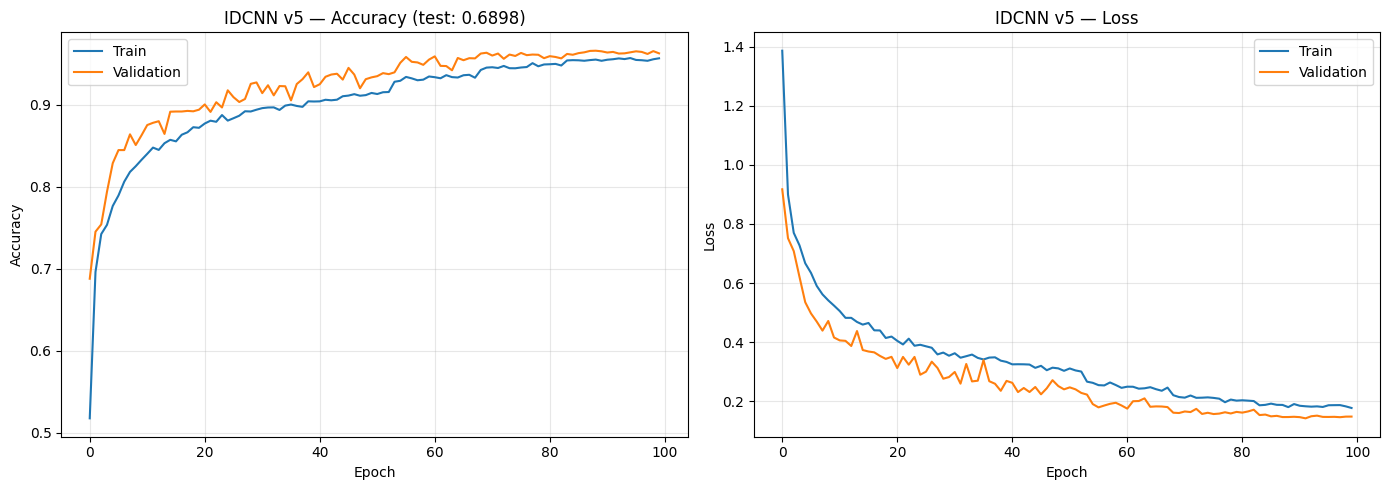

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title(f'IDCNN v5 — Accuracy (test: {test_acc:.4f})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('IDCNN v5 — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'idcnn_v5_training_history.png', dpi=150)
plt.show()

2026-05-08 06:53:50.914659: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


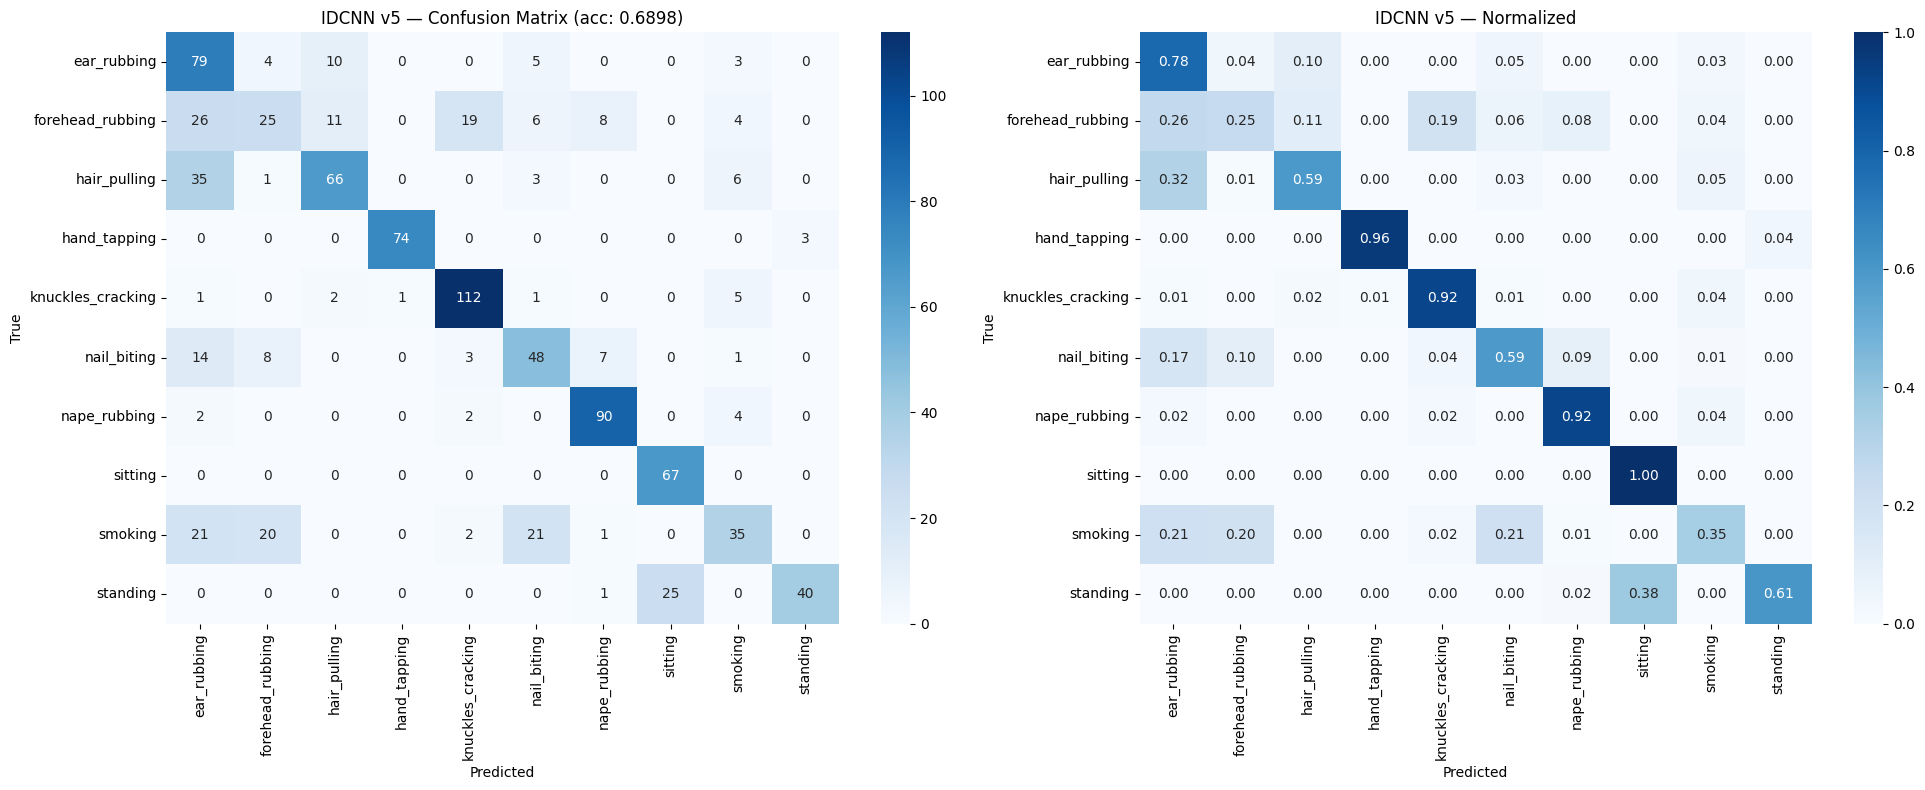

                   precision    recall  f1-score   support

      ear_rubbing     0.4438    0.7822    0.5663       101
 forehead_rubbing     0.4310    0.2525    0.3185        99
     hair_pulling     0.7416    0.5946    0.6600       111
     hand_tapping     0.9867    0.9610    0.9737        77
knuckles_cracking     0.8116    0.9180    0.8615       122
      nail_biting     0.5714    0.5926    0.5818        81
     nape_rubbing     0.8411    0.9184    0.8780        98
          sitting     0.7283    1.0000    0.8428        67
          smoking     0.6034    0.3500    0.4430       100
         standing     0.9302    0.6061    0.7339        66

         accuracy                         0.6898       922
        macro avg     0.7089    0.6975    0.6860       922
     weighted avg     0.6985    0.6898    0.6773       922



In [7]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax1)
ax1.set_title(f'IDCNN v5 — Confusion Matrix (acc: {test_acc:.4f})')
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax2)
ax2.set_title('IDCNN v5 — Normalized')
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'idcnn_v5_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=ACTIVITIES, digits=4))

## Comparison

In [8]:
print('VERSION COMPARISON')
print('=' * 60)
print(f'{"":20s} {"v2 (6f, 11c)":>14s} {"v3 (8f, 11c)":>14s} {"v4 (8f, 10c)":>14s}')
print('-' * 60)
print(f'{"Activities":20s} {"11":>14s} {"11":>14s} {"10":>14s}')
print(f'{"Features":20s} {"6":>14s} {"8":>14s} {"8":>14s}')
print(f'{"Per-user norm":20s} {"No":>14s} {"Yes":>14s} {"Yes":>14s}')
print(f'{"Test accuracy":20s} {"0.5963":>14s} {"0.6719":>14s} {test_acc:>14.4f}')
print(f'\nv4 vs v2: {(test_acc - 0.5963)*100:+.2f} pp')
print(f'v4 vs v3: {(test_acc - 0.6719)*100:+.2f} pp')

VERSION COMPARISON
                       v2 (6f, 11c)   v3 (8f, 11c)   v4 (8f, 10c)
------------------------------------------------------------
Activities                       11             11             10
Features                          6              8              8
Per-user norm                    No            Yes            Yes
Test accuracy                0.5963         0.6719         0.6898

v4 vs v2: +9.35 pp
v4 vs v3: +1.79 pp


## Save

In [9]:
model.save(MODEL_DIR / 'best_model_v5.h5')

# Also save config.h and model_data.h to models/ root for deployment
DEPLOY_DIR = Path('../models')

training_info = {
    'best_model': 'IDCNN_v5',
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'num_classes': NUM_CLASSES,
    'activities': ACTIVITIES,
    'window_size': WINDOW_SIZE,
    'num_features': NUM_FEATURES,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'l2_reg': L2_REG,
    'class_weights': class_weights,
    'history': history.history,
    'params': model.count_params(),
}

with open(MODEL_DIR / 'training_info_v5.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f'Model saved to {MODEL_DIR}/best_model_v5.h5')
print(f'Parameters: {model.count_params():,}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'\nNext: run 04_quantization_v5.ipynb')

Model saved to ../models/v5/best_model_v5.h5
Parameters: 47,242
Test accuracy: 0.6898

Next: run 04_quantization_v5.ipynb
